# Mapa de percepción de riesgo

El presente código tiene que ser capaz de cargar los tweets, clasificarlos, hacerles el análisis de sentimiento, extraer las entidades de nombradas y generar un mapa inicial

1. Cargando librerías

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
import evaluate
import seaborn as sns
import matplotlib.pyplot as plt

/Users/daniel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/daniel/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## clasificación

In [ ]:
# Cargar los datos
#df = pd.read_csv("concatenados_tweets.csv")
df = pd.read_csv('Tweets_procesados_expo.csv')

# Filtrar columnas necesarias
df = df[['Texto', 'Tipo']].dropna()
df = df[df['Texto'].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)]

# Codificar etiquetas
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Tipo'])

# Dividir en entrenamiento y prueba
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Texto'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# Tokenización con BETO
tokenizer = BertTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

# Crear datasets
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels
})
test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels
})

# Cargar métrica F1
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

# Modelo BERT para clasificación
model = BertForSequenceClassification.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased",
    num_labels=len(label_encoder.classes_)
)

# Configuración de entrenamiento
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",         
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

# Entrenador
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)
# Entrenar el modelo
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/bs/dp3478zn0bd_r77fww4bz5w40000gn/T/ipykernel_13137/3157447842.py:64: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/daniel/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG17GFamilyCommandBuffer: 0x956259180>
    label = <none> 
    device = <AGXG17GDevice: 0x956a28000>
        name = Apple M5 
    commandQueue = <AGXG17GFamilyCommandQueue: 0x104d663a0>
        label = <none> 
        device = <AGXG17GDevice: 0x956a28000>
            name = Apple M5 
    retainedReferences = 1
Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG17GFamilyCommandBuffer: 0x959f28700>
    label = <none> 
    device = <AGXG17GDevice: 0x956a28000>
        name = Apple M5 
    commandQueue = <AGXG17GFamilyCommandQueue: 0x104d663a0>
        label = <none> 
        device = <AGXG17GDev

/Users/daniel/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Clasification Report:
                    precision    recall  f1-score   support

            crimen       0.70      0.64      0.67        11
          incendio       0.95      0.95      0.95        44
        inundación       0.99      0.99      0.99        82
            lluvia       0.99      0.98      0.99       406
   no se relaciona       0.97      0.97      0.97       547
problema eléctrico       0.96      0.98      0.97        45
     problema vial       0.97      0.97      0.97       183

          accuracy                           0.97      1318
         macro avg       0.93      0.93      0.93      1318
      weighted avg       0.97      0.97      0.97      1318



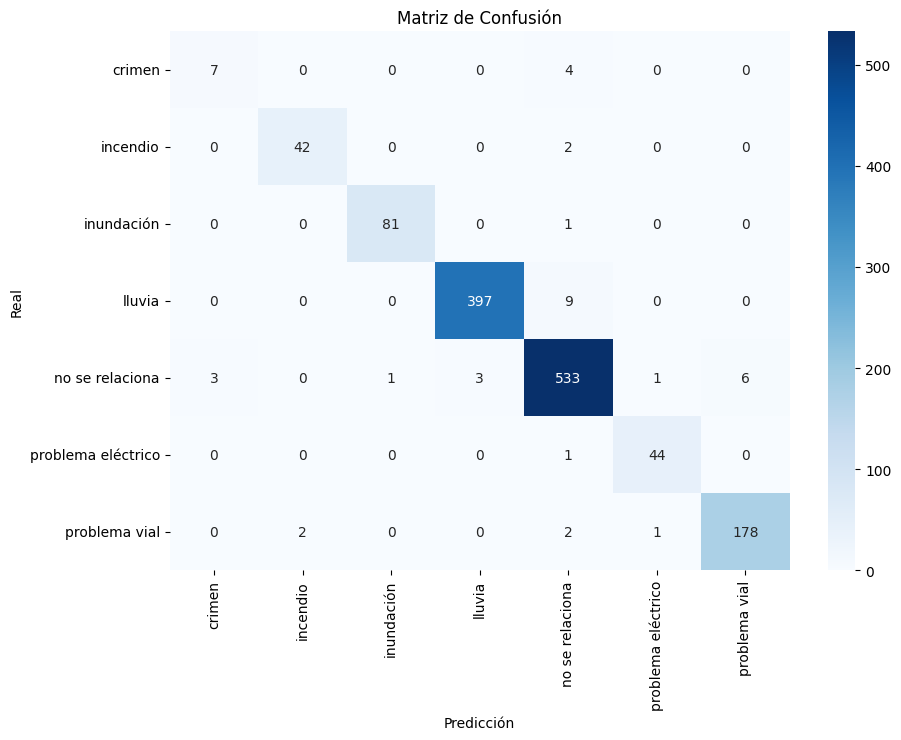

In [6]:
# Obtener predicciones
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Clasificación
print("Clasification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Guardando modelo

In [7]:
# Guardar el modelo con nombre personalizado
trainer.save_model("my_model11")

In [2]:
# Cargar modelo y tokenizer entrenado
model = BertForSequenceClassification.from_pretrained("my_model11")
tokenizer = BertTokenizer.from_pretrained("my_model11")


Probando modelo DEMO

In [ ]:
# Texto a evaluar
text = "fuertes lluvias en la avenida"

# Tokenizar
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

# Modo evaluación
model.eval()

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# Predicción (índice)
pred_class_id = torch.argmax(logits, dim=1).item()

# Mapear a etiqueta real
pred_label = label_encoder.classes_[pred_class_id]

print(f"Predicción: {pred_class_id}")

NameError: name 'label_encoder' is not defined

# Análisis de sentimiento

In [33]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import pandas as pd
import numpy as np
import torch

# Carga el archivo de tweets procesados
df = pd.read_csv('Tweets_procesados_expo.csv')

# Selecciona un modelo adecuado para español
MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Define las etiquetas de sentimiento
sentiment_labels = [-2, -1, 0, 1, 2]

# Función para calcular el sentimiento de cada texto
def calculate_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    outputs = model(**inputs)
    scores = outputs.logits.detach().numpy()[0]
    scores = softmax(scores)  # Aplica softmax para obtener las probabilidades
    sentiment_score = sum([a * b for a, b in zip(sentiment_labels, scores)])
    return sentiment_score


# Aplica la función a la columna 'Texto' y guarda el resultado en una nueva columna llamada 'Puntaje'
df['Puntaje'] = df['Texto'].apply(calculate_sentiment)

# Guarda el DataFrame actualizado en un nuevo archivo CSV
df.to_csv('Sentiment_CA.csv', index=False)


# NER

In [ ]:
import spacy
import pandas as pd 
from spacy.training.example import Example
import random
from spacy.util import minibatch, compounding
nlp = spacy.load("es_core_news_lg")
# Getting the pipeline component
ner=nlp.get_pipe("ner")

Entrenamiento

In [ ]:
#df_random = pd.read_csv("concatenados_tweets.csv")
df_random = pd.read_csv("COMPLETE_sample.csv")

In [ ]:
TRAIN_DATA = [("cuidadodelagua sin suministro de agua en la colonia bosques de la huasteca santacatarina vía nessspartan cc aydmonterrey", {"entities":[(44, 74, "COL"), (75, 89, "MUN"), (108,120, "ORG")]}),
              ("cuidadodelagua servicio de agua con aspecto turbio en la colonia vista hermosa monterrey vía carmengina cc aydmonterrey",{"entities":[(57, 78, "COL"), (79, 88, "MUN"), (107, 119, "ORG")]}),
              ("cuidadodelagua sin suministro de agua en la colonia villas del mirador", {"entities":[(44, 70, "COL")]}),
              ("peligro en el parque de la huasteca. Un coche se volcó.",{"entities":[(14, 35, "LOC")]}),
              ("Atención en col. San franciso de asis hay mucho trafico.", {"entities":[(12, 38, "COL")]}), 
              ("la col del valle se encuentra inundada, no manejes por ahi",{"entities":[(3, 16, "COL")]}), 
              ("fuertes lluvias en la av grza sada y reporte de inundación en col nuevo mexico",{"entities":[(22, 34, "CALLE"), (62, 78, "COL")]}),
              ("fuertes lluvias en avenida lincon, extrema precacaución con avenidas grandes",{"entities":[(19, 33, "COL")]}),
              ("la avenidad gonzalitos que conecta con la colonia del valle esta repleta de coches",{"entities":[(3, 22, "COL"), (42, 59, "COL")]}),
              ("cuidado en la av revolucion con cruce en av gonzalitos",{"entities":[(14, 28, "CALLE"), (40, 54, "CALLE")]}),
              ("col nuevo mexico en peligro, atentos residentes de monterrey ocurrio algo cerca de la ave ignacio a",{"entities":[(0 ,16, "COL"), (51, 60, "MUN"), (86, 99, "CALLE")]}),
              (df_random["Texto"][0],{"entities" : [(55, 57, "GPE"), (125,140, "COL"), (141,150, "MUN"), (151, 153, "GPE")]}),
              (df_random["Texto"][1],{"entities" : [(38, 50, "COL")]}),
              (df_random["Texto"][3],{"entities" : [(65, 84, "REGION"), (91, 120, "CALLE"), (189, 199, "GPE"), (203,214, "ORG"), (215,220, "ORG")]}),
              (df_random["Texto"][4],{"entities" : [(20,34, "CALLE"), (37,53, "CALLE"), (148, 152, "MUN"), (153, 157, "ORG")]}),
              (df_random["Texto"][5],{"entities" : [(45, 55, "CALLE"), (127, 143, "CALLE"), (179, 192, "ORG")]}),
              (df_random["Texto"][6],{"entities" : [(20, 38, "CALLE"), (48, 58, "CALLE"), (152, 156, "MUN"), (157 ,161, "ORG")]}),
              (df_random["Texto"][7],{"entities" : [(40, 58, "LOC"), (67, 84 , "FAC"), (88, 97, "MUN"), (98, 100, "GPE"), (209 ,218, "ORG"), (219, 229, "ORG"), (229, 243, "ORG")]}),
              (df_random["Texto"][8],{"entities" : [(74, 96, "LOC"), (109, 128, "COL"), (128, 132, "MUN"), (133, 137, "ORG")]}),
              (df_random["Texto"][10],{"entities" : [(72, 83, "MUN"), (86 ,104, "REGION"), (192, 201, "MUN"), (255, 260, "ORG"), (261, 273, "ORG")]}),
              (df_random["Texto"][11],{"entities" : [(77, 80, "MUN")]}),
              (df_random["Texto"][12],{"entities" : [(32, 42,"GPE"), (89, 127, "REGION")]}),
              (df_random["Texto"][14],{"entities" : [(60, 70,"GPE")]}),
              (df_random["Texto"][15],{"entities" : [(32, 46, "FAC"), (129, 136, "MUN")]}),
              (df_random["Texto"][17],{"entities" : [(35, 55, "CALLE"), (58 ,77, "CALLE"), (149, 167, "LOC")]}),
              (df_random["Texto"][16],{"entities" : [(6, 15, "MUN")]}),
              (df_random["Texto"][19],{"entities" : [(44, 62, "FAC"), (63, 72, "MUN"), (73, 75, "GPE")]}),
              (df_random["Texto"][20],{"entities" : [(32, 42, "MUN"), (129 ,142, "ORG")]}),
              (df_random["Texto"][21],{"entities" : [(56, 86, "REGION")]}),
              (df_random["Texto"][22],{"entities" : [(46, 67, "REGION")]}),
              (df_random["Texto"][23],{"entities" : [(40, 55, "REGION"), (154, 171, "REGION")]}),
              (df_random["Texto"][24],{"entities" : [(9, 19, "GPE"), (85, 106, "COL"), (110, 119, "MUN")]}),
              (df_random["Texto"][26],{"entities" : [(25, 34, "GPE"), (102, 120, "FAC"), (139, 156, "FAC")]}),
              (df_random["Texto"][27],{"entities" : [(20, 43, "CALLE"), (46, 55, "MUN")]}),
              (df_random["Texto"][30],{"entities" : [(39, 57, "LOC")]}),
              (df_random["Texto"][32],{"entities" : [(12, 30, "LOC")]}),
              (df_random["Texto"][33],{"entities" : [(17, 32, "CALLE"), (35, 49, "CALLE"), (143, 147, "MUN"), (148, 152, "ORG")]}),
              (df_random["Texto"][34],{"entities" : [(9, 11, "GPE"), (61, 89, "REGION")]}),
              (df_random["Texto"][35],{"entities" : [(29, 39, "LOC"), (40, 47, "LOC")]}),
              (df_random["Texto"][36],{"entities" : [(36, 51, "LOC"), (197, 207, "GPE")]}),
              (df_random["Texto"][40],{"entities" : [(131,142, "ORG"), (210, 241, "REGION")]}),
              (df_random["Texto"][41],{"entities" : [(39, 46, "MUN"), (152, 162, "ORG")]}),
              (df_random["Texto"][42],{"entities" : [(69, 87, "LOC"), (91, 100, "MUN"), (224,229, "ORG"), (232, 243, "ORG")]}),
              (df_random["Texto"][43],{"entities" : [(44, 56, "CALLE"), (62, 78, "CALLE")]}),
              (df_random["Texto"][44],{"entities" : [(35, 45, "ORG"), (104, 122, "CALLE"), (125, 137, "CALLE"), (138, 142, "MUN"), (143, 147, "ORG")]}),
              (df_random["Texto"][45],{"entities" : [(21, 38, "CALLE"), (41, 47, "CALLE"), (51, 61, "MUN")]}),
              (df_random["Texto"][46],{"entities" : [(25,35, "CALLE"), (38, 51, "CALLE"), (81, 93, "FAC"), (129, 142, "ORG")]}),
              (df_random["Texto"][47],{"entities" : [(14,31, "CALLE"), (37, 47, "CALLE"), (48, 55, "MUN"), (138, 150, "ORG")]}),
              (df_random["Texto"][49],{"entities" : [(33, 47, "MUN")]})
              ]
# Adding labels to the `ner`
for _, annotations in TRAIN_DATA:
  for ent in annotations.get("entities"):
    ner.add_label(ent[2])

In [ ]:
def findWord(texto, palabra):
    indice1 = texto.find(palabra)
    return [indice1, indice1 + len(palabra)]

st = df_random["Texto"][40]
print(st)
indices = findWord(st, "santa catarina")
print(indices)
print(st[indices[0]:indices[1]])

In [ ]:
pipe_exceptions = ["ner"]
unaffected_pipes = [pipe for pipe in nlp.pipe_names if pipe not in pipe_exceptions]

# Training the model
with nlp.disable_pipes(*unaffected_pipes):  # Only train NER
    optimizer = nlp.begin_training()
    for iteration in range(300):
        random.shuffle(TRAIN_DATA)
        losses = {}
        
        # Batch up the examples using spaCy's minibatch
        batches = minibatch(TRAIN_DATA, size=compounding(4.0, 32.0, 1.001))
        for batch in batches:
            texts, annotations = zip(*batch)
            
            # Convert to Example objects
            examples = []
            for i in range(len(texts)):
                doc = nlp.make_doc(texts[i])
                example = Example.from_dict(doc, annotations[i])
                examples.append(example)
            
            # Update the model with the Example objects
            nlp.update(examples, drop=0.5, losses=losses)
        
        print(f"Iteration {iteration}: Losses", losses)

Probando modelo

In [ ]:
# Testing the model
doc = nlp("Está lloviendo en la colonia del valle")
print("Entities", [(ent.text, ent.label_) for ent in doc.ents])

Guardando modelo

In [ ]:
# Save the  model to directory
name = "NER_MODEL_1"
nlp.to_disk(name)
print("Saved model")

In [ ]:
# Cargar el modelo personalizado de spaCy
# Asegúrate de reemplazar 'ner_model' por el nombre real de tu carpeta de modelo
nlp = spacy.load("NER_MODEL_1")

# Cargar los tweets
df = pd.read_csv("tweets_concatenados_globales.csv")

# Asegúrate de que hay una columna 'Texto' (ajusta si tiene otro nombre)
def extraer_entidades(texto):
    doc = nlp(str(texto))
    municipio = []
    colonia = []
    calle = []

    for ent in doc.ents:
        if ent.label_ == "MUN":
            municipio.append(ent.text)
        elif ent.label_ == "COL":
            colonia.append(ent.text)
        elif ent.label_ == "CALLE":
            calle.append(ent.text)

    # Devolver como strings separados por comas si hay múltiples
    return pd.Series({
        "municipio": ", ".join(municipio) if municipio else None,
        "colonia": ", ".join(colonia) if colonia else None,
        "calle": ", ".join(calle) if calle else None
    })

# Aplicar a cada fila del DataFrame
entidades_extraidas = df["Texto"].apply(extraer_entidades)

# Unir los resultados al dataframe original
df_resultado = pd.concat([df, entidades_extraidas], axis=1)

# Guardar el resultado a un nuevo CSV
df_resultado.to_csv("tweets_concatenados_entidades_CA.csv", index=False)

print("¡Proceso completado! El archivo 'tweets_con_entidades.csv' ha sido generado.")


# Geolocalizador

In [23]:
import ast

def safe_convert_to_list(value):
    try:
        if isinstance(value, list):
            return value
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

In [32]:
import pandas as pd
import geopandas as gpd
from geopy.geocoders import Nominatim
import time
from shapely.geometry import Point
import os
import json
import folium
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm

# Inicializar el geolocalizador
geolocator = Nominatim(user_agent="mi_aplicacion_mapa")
# Cargar los shapefiles
shapefile_municipios = "2023_1_19_A/2023_1_19_A.shp"
shapefile_colonias = "Colonias/Colonias.shp"
gdf_municipios = gpd.read_file(shapefile_municipios)
gdf_colonias = gpd.read_file(shapefile_colonias)
gdf_colonias = gdf_colonias[gdf_colonias["ST_NAME"] == "NUEVO LEON"]
# Cargar el archivo CSV
df_calles = pd.read_csv("Tweets_procesados_expo3.csv")
df_calles = df_calles[~df_calles['municipio'].isin(['monte morelos', 'saltillo'])]
df_calles['colonia'] = df_calles['colonia'].str.upper()

# Resetear índice para evitar inconsistencias
df_calles = df_calles.reset_index(drop=True)

# Crear ID incremental
df_calles['ID'] = df_calles.index + 1

# (Opcional pero recomendado) asegurar tipo entero
df_calles['ID'] = df_calles['ID'].astype(int)

# Verificar
print(df_calles[['ID']].head())


# Filtrar municipios y calcular puntaje promedio
cve_mun_values = {
    '006': 'apodaca',
    '019': 'san pedro garza garcía',
    '021': 'escobedo',
    '026': 'guadalupe',
    '039': 'monterrey',
    '046': 'san nicolás',
    '048': 'santa catarina',
    '049': 'santiago'
}
promedio_puntajes_municipios = {}
for cve, municipio in cve_mun_values.items():
    filas_municipio = df_calles[df_calles['municipio'].str.lower() == municipio.lower()]
    if not filas_municipio.empty:
        promedio_puntajes_municipios[cve] = np.mean(filas_municipio['Puntaje'])
    else:
        promedio_puntajes_municipios[cve] = None

gdf_municipios['Puntaje'] = gdf_municipios['CVE_MUN'].map(promedio_puntajes_municipios)

# Crear el mapa con Folium
mapa = folium.Map(location=[25.6866, -100.3161], zoom_start=13)
municipios_layer = folium.FeatureGroup(name='Municipios')
colonias_layer = folium.FeatureGroup(name='Colonias')
calles_layer = folium.FeatureGroup(name='Calles')

# Añadir municipios al mapa
norm_municipios = Normalize(vmin=-2, vmax=2)
cmap_municipios = cm.get_cmap('RdYlGn')

for _, row in gdf_municipios.iterrows():
    puntaje = row['Puntaje']
    if puntaje is not None:
        color = cmap_municipios(norm_municipios(puntaje))[:3]
        color = [int(c * 255) for c in color]
        folium.GeoJson(
            row['geometry'],
            style_function=lambda x, color=color: {
                'fillColor': f'rgba({color[0]}, {color[1]}, {color[2]}, 0.6)',
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0.6,
            }
        ).add_to(municipios_layer)

# Añadir colonias al mapa

# Convertir los nombres de las colonias en df_calles a mayúsculas
df_calles['colonia'] = df_calles['colonia'].str.upper()

# Crear un diccionario para almacenar los promedios de puntajes por colonia
promedio_puntajes_colonia = {}

# Obtener la lista de colonias únicas en df_calles
colonias_unicas = df_calles['colonia'].unique()

# Calcular el promedio de puntajes para cada colonia
for colonia in colonias_unicas:
    # Filtrar el DataFrame por la colonia actual
    filas_colonia = df_calles[df_calles['colonia'] == colonia]
    
    if not filas_colonia.empty:
        # Calcular el promedio de puntajes para la colonia
        promedio_puntajes_colonia[colonia] = np.mean(filas_colonia['Puntaje'])
    else:
        # Asignar None si no hay registros para la colonia
        promedio_puntajes_colonia[colonia] = None

# Asignar estos promedios a df_calles
df_calles['Promedio_Puntaje'] = df_calles['colonia'].map(promedio_puntajes_colonia)

# Supongamos que gdf_colonias es tu GeoDataFrame
# Convertir los nombres de las colonias en gdf_colonias a mayúsculas también (ajusta el nombre de la columna según tu caso)
gdf_colonias['SETT_NAME'] = gdf_colonias['SETT_NAME'].str.upper()

# Realizar el merge entre gdf_colonias y df_calles
promedio_puntajes_colonia = pd.DataFrame(list(promedio_puntajes_colonia.items()), columns=['colonia', 'Puntaje'])
gdf_colonias = gdf_colonias.merge(promedio_puntajes_colonia, left_on='SETT_NAME', right_on='colonia', how='left')


gdf_municipios['Puntaje'] = gdf_municipios['CVE_MUN'].map(promedio_puntajes_municipios)
norm_colonias = Normalize(vmin=df_calles['Puntaje'].min(), vmax=df_calles['Puntaje'].max())
cmap_colonias = cm.get_cmap('RdYlGn')

for _, row in gdf_colonias.iterrows():
    puntaje = row['Puntaje']
    if puntaje is not None:
        color = cmap_colonias(norm_colonias(puntaje))[:3]
        color = [int(c * 255) for c in color]
        folium.GeoJson(
            row['geometry'],
            style_function=lambda x, color=color: {
                'fillColor': f'rgba({color[0]}, {color[1]}, {color[2]}, 0.6)',
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0.4,
            }
        ).add_to(colonias_layer)

# Añadir capas al mapa
municipios_layer.add_to(mapa)
colonias_layer.add_to(mapa)
folium.LayerControl().add_to(mapa)

# Guardar archivos SHP
gdf_municipios.to_file('ArcGis/puntaje_municipios2.shp')
print("Shapefile de municipios creado")
gdf_colonias.to_file('ArcGis/puntaje_colonias2.shp')
print("Shapefile de colonias creado")

# Archivo para guardar el último ID procesado
ultimo_id_file_path = "ultimo_id_procesado2.json"

# Leer el último ID procesado desde el archivo, si existe
if os.path.exists(ultimo_id_file_path):
    with open(ultimo_id_file_path, 'r') as file:
        ultimo_id_procesado = json.load(file).get('ultimo_id', 0)
else:
    ultimo_id_procesado = 0

# Filtrar el DataFrame para obtener solo las filas con ID mayor al último procesado
df_nuevas_filas = df_calles[df_calles['ID'] > ultimo_id_procesado]

# Si hay nuevas filas para procesar
if not df_nuevas_filas.empty:
    municipios_lista = ['Monterrey', 'Apodaca', 'San Pedro Garza García', 'Escobedo', 'Guadalupe', 'San Nicolás', 'Santa Catarina', 'Santiago']
    datos_geo = []

    for idx, row in df_nuevas_filas.iterrows():
        calles_lista = row['calle']
        puntaje = row['Puntaje']  # Obtener el puntaje de la calle
        tipo = row['Tipo']  # Obtener la clasificación de la calle

        # Asegurarse de que el valor de 'calle' es una cadena
        if isinstance(calles_lista, str):
            calles_lista = [calle.strip() for calle in calles_lista.split(',')]

        # Iterar sobre las calles de la fila
        if isinstance(calles_lista, list) and calles_lista:
            for calle in calles_lista:
                if calle and "[]" not in calle:  # Asegurarse de que la calle no esté vacía
                    found_location = False
                    for municipio in municipios_lista:
                        try:
                            # Intentar geolocalizar la calle
                            location = geolocator.geocode(calle + ", " + municipio + ", Mexico")
                            time.sleep(1)  # Evitar sobrecarga del servicio
                            if location:
                                # Guardar los datos geográficos
                                datos_geo.append({
                                    'calle': calle,
                                    'puntaje': puntaje,
                                    'tipo': tipo,
                                    'geometry': Point(location.longitude, location.latitude)
                                })
                                found_location = True
                                print(f"Se obtuvieron las coordenadas para {calle} en {municipio}")
                                break
                        except Exception as e:
                            print(f"Error al intentar obtener las coordenadas para {calle} en {municipio}: {e}")                   
                    if not found_location:
                        print(f"No se encontraron coordenadas para {calle} en ningún municipio.")    
    # Convertir los datos de calles nuevas a GeoDataFrame
    gdf_nuevas_calles = gpd.GeoDataFrame(datos_geo, geometry='geometry')
    gdf_nuevas_calles.set_crs(epsg=4326, inplace=True)

    # Verificar si ya existe el archivo SHP anterior
    shp_file_path = 'ArcGis/puntaje_calles2.shp'
    
    if os.path.exists(shp_file_path):
        # Si ya existe, cargar los datos antiguos y anexar las nuevas filas
        gdf_calles_existente = gpd.read_file(shp_file_path)
        gdf_calles_actualizado = pd.concat([gdf_calles_existente, gdf_nuevas_calles], ignore_index=True)
    else:
        # Si no existe, simplemente usar las nuevas filas
        gdf_calles_actualizado = gdf_nuevas_calles

    # Guardar el archivo SHP actualizado con los datos anteriores y los nuevos
    gdf_calles_actualizado.to_file(shp_file_path)
    print("Shapefile de calles creado")

   # Actualizar el último ID procesado
    nuevo_ultimo_id = int(df_nuevas_filas['ID'].max())
    try:
        with open(ultimo_id_file_path, 'w') as file:
            json.dump({'ultimo_id': nuevo_ultimo_id}, file)
            file.flush()  # Asegura que los datos se envíen al disco inmediatamente
    except Exception as e:
        print(f"Error al escribir el archivo JSON: {e}")
else:
    print("No hay nuevas filas para procesar.")
# Guardar el mapa en un archivo HTML
mapa.save("mapa_interactivo_CA.html")




   ID
0   1
1   2
2   3
3   4
4   5


/var/folders/bs/dp3478zn0bd_r77fww4bz5w40000gn/T/ipykernel_11021/516904255.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_municipios = cm.get_cmap('RdYlGn')
/var/folders/bs/dp3478zn0bd_r77fww4bz5w40000gn/T/ipykernel_11021/516904255.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_colonias = cm.get_cmap('RdYlGn')


Shapefile de municipios creado
Shapefile de colonias creado


/Users/daniel/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 700010164 of field AREA of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/daniel/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 700010165 of field AREA of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/daniel/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 700010165 of field AREA of feature 2 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/daniel/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 700010165 of field AREA of feature 3 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/daniel/Library/Python/3.9/lib/python/site

Se obtuvieron las coordenadas para Avenida Matehuala en Monterrey
Se obtuvieron las coordenadas para Avenida Lázaro Cárdenas en Monterrey
Se obtuvieron las coordenadas para Julian Villarreal en Monterrey
Se obtuvieron las coordenadas para Calle Serafín Peña en Monterrey
Se obtuvieron las coordenadas para Calle Felipe Carrillo en Monterrey
Se obtuvieron las coordenadas para Avenida Rodrigo Gómez en Monterrey
Se obtuvieron las coordenadas para Avenida Penitenciaría en Monterrey
Se obtuvieron las coordenadas para Peñasco del Acantilado en Monterrey
Se obtuvieron las coordenadas para Andrómeda en Monterrey
Se obtuvieron las coordenadas para Avenida Constitución en Monterrey
Se obtuvieron las coordenadas para Paseo San Ángel en Monterrey
Se obtuvieron las coordenadas para Avenida Abraham Lincoln en Monterrey
Se obtuvieron las coordenadas para Avenida Ruíz Cortines en Monterrey
Se obtuvieron las coordenadas para Avenida Aztlán en Monterrey
Se obtuvieron las coordenadas para Avenida Rodrigo G